# Baseline models

Goal: Make baseline predictions by averaging rain, crop, and surplus data over the entire basin for a single site.
Currently using site WQS0039 but can be updated to any uid.

To do:
- Normalize crops over basin area
- Normalize rain over basin area
- Create surplus x rain data per day by using the surplus data in 2017 at each grid (needs grid_id added to rain data)
- Explore different features, determine if any are good. Where to do this is indicated later on.
- Additional EDA beyond pair plot, test with other basins
- Create baseline model for multiple sites and test on a separate site

In [142]:
import sys
sys.path.insert(0, "../") # replace with path/to/project/root
from data import get_data, get_site_ids

import pandas as pd
import numpy as np


In [143]:
uid = "WQS0039"

data = get_data(site_uid=uid)

rain = data.rain
daily_avg_precip = ( # calculate average percipitation over entire basin for each date
    rain.groupby("date", as_index=False)["precip_in_1d"]
      .mean()
)

# Take sum of crops over the entire basin (figure out how to normalized)
crops = data.crops.groupby("year", as_index=False).sum() 

# Calculate mean surplus nitrogen over basin in 2017. This does not work as a feature because it is constant.
nitrogen_2017 = data.surplus[data.surplus['year'] == 2017]
SURPLUS_N_2017 = nitrogen_2017['surplus_kgha'].mean()


In [144]:
data.rain.describe()

,date,lon,lat,precip_in_1d,year,month,day_of_year,week
count,180336,180336.000000,180336.000000,180336.000000,180336.000000,180336.000000,180336.000000,180336.000000
mean,2019-06-10 16:52:06.643000,-93.928223,42.944792,0.108346,2018.944637,6.479239,181.771194,26.363322
min,2016-04-07 00:00:00,-94.155130,42.709941,0.000000,2016.000000,1.000000,1.000000,1.000000
25%,2017-11-05 18:00:00,-94.019968,42.853743,0.000000,2017.000000,4.000000,97.000000,14.000000
50%,2019-06-06 12:00:00,-93.927397,42.948071,0.000000,2019.000000,6.000000,179.500000,26.000000
75%,2021-01-13 06:00:00,-93.835306,43.034954,0.050000,2021.000000,9.000000,269.250000,39.000000
max,2022-08-14 00:00:00,-93.710616,43.148704,5.510000,2022.000000,12.000000,366.000000,53.000000
std,NaN,0.114332,0.111901,0.301737,1.871633,3.372309,103.118445,14.725804


In [145]:
crops

,year,node_id,Alfalfa,Corn,Fallow,Hay_Pasture,Nonag,Other,Small_Grains,Soybeans
0,2000,3003,0,754325,9217,88945,6136,0,1755,738083
1,2001,3003,3712,922661,31898,102165,11277,0,18381,508367
2,2002,3003,0,761726,21888,170657,17172,166,0,626852
3,2003,3003,1150,808105,15236,61302,12780,3222,969,695697
4,2004,3003,9721,739643,18205,91681,63975,3016,1764,670456
5,2005,3003,600,679081,2055,147435,107514,1427,726,659623
6,2006,3003,1432,222478,2981,8686,31395,2,286,191489
7,2007,3003,304,245118,4,17012,45439,3,64,150805
8,2008,3003,1903,812704,15,85306,115507,2,171,582853
9,2009,3003,1287,791890,1,77526,115240,73,231,612213


In [146]:
from data.water import aggregate_by_interval

# Aggregate water levels to each calendar day. I used max so we coult track violations,
# but might need to be average for a continuous model. This could explain why linreg is so bad.
water = aggregate_by_interval(site_uid=uid, value_col="nitrate_con", interval="1D", agg_func="max").to_frame()
water["date"] = water.index.date

water = water.reset_index(drop=True)

# Create true/false column if there was a single violation in a calendar day
water["violation"] = (water.nitrate_con > 10).astype(int)
print("Violation counts:\n", water["violation"].value_counts()) # Check counts of violations
water



Violation counts:
 violation
0    1869
1     452
Name: count, dtype: int64


,nitrate_con,date,violation
0,4.30,2016-04-07,0
1,4.33,2016-04-08,0
2,4.15,2016-04-09,0
3,4.19,2016-04-10,0
4,4.22,2016-04-11,0
...,...,...,...
2316,1.04,2022-08-10,0
2317,1.58,2022-08-11,0
2318,3.21,2022-08-12,0
2319,2.82,2022-08-13,0


In [147]:
# Make datetime stuff compatible
water["date"] = pd.to_datetime(water["date"])
daily_avg_precip["date"] = pd.to_datetime(daily_avg_precip["date"])


# Merge water data with daily average percipitation
df = water[["date", "violation", "nitrate_con"]].merge(
    daily_avg_precip,
    on="date",
    how="left"
)
df


,date,violation,nitrate_con,precip_in_1d
0,2016-04-07,0,4.30,0.025897
1,2016-04-08,0,4.33,0.005385
2,2016-04-09,0,4.15,0.000000
3,2016-04-10,0,4.19,0.079103
4,2016-04-11,0,4.22,0.000000
...,...,...,...,...
2316,2022-08-10,0,1.04,0.000000
2317,2022-08-11,0,1.58,0.009487
2318,2022-08-12,0,3.21,0.000000
2319,2022-08-13,0,2.82,0.000128


In [148]:
# Add in 7,14, and 30 day rolling averages
df["rain_7d"]  = df["precip_in_1d"].rolling(7,  min_periods=1).sum()
df["rain_14d"] = df["precip_in_1d"].rolling(14, min_periods=1).sum()
df["rain_30d"] = df["precip_in_1d"].rolling(30, min_periods=1).sum()

# Crop data is yearly -> broadcast onto every day in that crop year.
df["year"] = df["date"].dt.year
df = df.merge(crops.drop(columns='node_id'), on="year", how="left")      
 
# Surplus N is a single static estimate -> constant column. Will only matter for multiple sites.
df["surplus_n_2017"] = SURPLUS_N_2017

# Use Surplus N as a feature to explain rain. This should be adjusted to be weighted across the grid, but WIP.
df["surplus_x_rain30"] = df["surplus_n_2017"] * df["rain_30d"]
 
# Autoregressive features: nitrate is autocorrelated, recent readings matter
df["nitrate_lag1"] = df["nitrate_con"]            # today's reading
df["nitrate_lag2"] = df["nitrate_con"].shift(1)
df["nitrate_lag3"] = df["nitrate_con"].shift(2)

df


,date,violation,nitrate_con,precip_in_1d,rain_7d,rain_14d,rain_30d,year,Alfalfa,Corn,...,Hay_Pasture,Nonag,Other,Small_Grains,Soybeans,surplus_n_2017,surplus_x_rain30,nitrate_lag1,nitrate_lag2,nitrate_lag3
0,2016-04-07,0,4.30,0.025897,0.025897,0.025897,0.025897,2016,1453,884967,...,61137,125475,93,946,524390,115.68236,2.995877,4.30,NaN,NaN
1,2016-04-08,0,4.33,0.005385,0.031282,0.031282,0.031282,2016,1453,884967,...,61137,125475,93,946,524390,115.68236,3.618782,4.33,4.30,NaN
2,2016-04-09,0,4.15,0.000000,0.031282,0.031282,0.031282,2016,1453,884967,...,61137,125475,93,946,524390,115.68236,3.618782,4.15,4.33,4.30
3,2016-04-10,0,4.19,0.079103,0.110385,0.110385,0.110385,2016,1453,884967,...,61137,125475,93,946,524390,115.68236,12.769553,4.19,4.15,4.33
4,2016-04-11,0,4.22,0.000000,0.110385,0.110385,0.110385,2016,1453,884967,...,61137,125475,93,946,524390,115.68236,12.769553,4.22,4.19,4.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2316,2022-08-10,0,1.04,0.000000,1.750897,1.917436,2.769872,2022,4114,760726,...,69404,104569,34,1793,657821,115.68236,320.425307,1.04,2.11,1.26
2317,2022-08-11,0,1.58,0.009487,1.760385,1.822308,2.779359,2022,4114,760726,...,69404,104569,34,1793,657821,115.68236,321.522807,1.58,1.04,2.11
2318,2022-08-12,0,3.21,0.000000,1.760385,1.822308,2.779359,2022,4114,760726,...,69404,104569,34,1793,657821,115.68236,321.522807,3.21,1.58,1.04
2319,2022-08-13,0,2.82,0.000128,0.767436,1.822436,2.779359,2022,4114,760726,...,69404,104569,34,1793,657821,115.68236,321.522807,2.82,3.21,1.58


In [149]:
# Add in columns that allow for dummy models (yesterday's value = today's value)
df["nitrate_tomorrow"]   = df["nitrate_con"].shift(-1)
df["violation_tomorrow"] = (df["nitrate_tomorrow"] > 10).astype(int)
 
# Remove null variables
df = df.dropna(subset=["nitrate_tomorrow", "nitrate_lag3", "nitrate_con"]).reset_index(drop=True)
df  # Look at all features in dataframe

,date,violation,nitrate_con,precip_in_1d,rain_7d,rain_14d,rain_30d,year,Alfalfa,Corn,...,Other,Small_Grains,Soybeans,surplus_n_2017,surplus_x_rain30,nitrate_lag1,nitrate_lag2,nitrate_lag3,nitrate_tomorrow,violation_tomorrow
0,2016-04-09,0,4.15,0.000000,0.031282,0.031282,0.031282,2016,1453,884967,...,93,946,524390,115.68236,3.618782,4.15,4.33,4.30,4.19,0
1,2016-04-10,0,4.19,0.079103,0.110385,0.110385,0.110385,2016,1453,884967,...,93,946,524390,115.68236,12.769553,4.19,4.15,4.33,4.22,0
2,2016-04-11,0,4.22,0.000000,0.110385,0.110385,0.110385,2016,1453,884967,...,93,946,524390,115.68236,12.769553,4.22,4.19,4.15,4.24,0
3,2016-04-12,0,4.24,0.000000,0.110385,0.110385,0.110385,2016,1453,884967,...,93,946,524390,115.68236,12.769553,4.24,4.22,4.19,4.28,0
4,2016-04-13,0,4.28,0.011026,0.121410,0.121410,0.121410,2016,1453,884967,...,93,946,524390,115.68236,14.045025,4.28,4.24,4.22,4.33,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1214,2022-08-09,0,2.11,0.000000,1.812436,2.078974,2.915769,2022,4114,760726,...,34,1793,657821,115.68236,337.303067,2.11,1.26,4.21,1.04,0
1215,2022-08-10,0,1.04,0.000000,1.750897,1.917436,2.769872,2022,4114,760726,...,34,1793,657821,115.68236,320.425307,1.04,2.11,1.26,1.58,0
1216,2022-08-11,0,1.58,0.009487,1.760385,1.822308,2.779359,2022,4114,760726,...,34,1793,657821,115.68236,321.522807,1.58,1.04,2.11,3.21,0
1217,2022-08-12,0,3.21,0.000000,1.760385,1.822308,2.779359,2022,4114,760726,...,34,1793,657821,115.68236,321.522807,3.21,1.58,1.04,2.82,0


In [150]:
# Check seasonality of violations. Indicate that this time series should possibly be handled as periodic/seasonal.

df["month"] = df["date"].dt.month
monthly = df.groupby("month")["violation_tomorrow"].agg(["sum", "count"])
monthly["rate"] = monthly["sum"] / monthly["count"]
print("Violations by month:\n", monthly, "\n")
 
top_month_share = monthly["sum"].max() / monthly["sum"].sum()
print(f"Largest single month holds {top_month_share:.0%} of all violations.")
if top_month_share > 0.35:
    print("WARNING: violations are heavily seasonal. A plain chronological "
          "split may starve some folds of positives -- consider checking "
          "fold-level violation counts below, or stratifying by season "
          "instead of pure date order.\n")
else:
    print("Violations are reasonably spread across the year.\n")


Violations by month:
        sum  count      rate
month                      
3        5     10  0.500000
4       26     99  0.262626
5       72    161  0.447205
6      130    186  0.698925
7       53    177  0.299435
8       14    124  0.112903
9       27    149  0.181208
10      63    145  0.434483
11      42    142  0.295775
12       2     26  0.076923 

Largest single month holds 30% of all violations.
Violations are reasonably spread across the year.



## Edit included features here!

In [ ]:
cutoff = df["date"].quantile(0.8)          # last ~20% of days held out
train = df[df["date"] <= cutoff]
hold_out  = df[df["date"] >  cutoff]
 
crop_cols = [c for c in crops.columns if c not in ["year", "node_id"]]

# PLAY AROUND HERE WITH DIFFERENT FEATURES TO DETERMINE WHICH ONES YOU WANT TO INCLUDE.
# ALL POSSIBLE FEATURES ARE INCLUDED IN THE commented feature_cols LIST.

# feature_cols = (["precip_in_1d", "rain_7d", "rain_14d", "rain_30d", "surplus_x_rain30",
#                   "nitrate_lag1", "nitrate_lag2", "nitrate_lag3"]
#                  + crop_cols)
feature_cols = (["precip_in_1d", "rain_7d", "rain_14d", "rain_30d", "surplus_x_rain30",
                  "nitrate_lag1", "nitrate_lag2", "nitrate_lag3"])
 
X = train[feature_cols].fillna(0).values    # train on all features for training data. Fix null values
y_class = train["violation_tomorrow"].values
y_reg   = train["nitrate_tomorrow"].values
today_value = train["nitrate_con"].values   # needed for the random-walk baseline

 

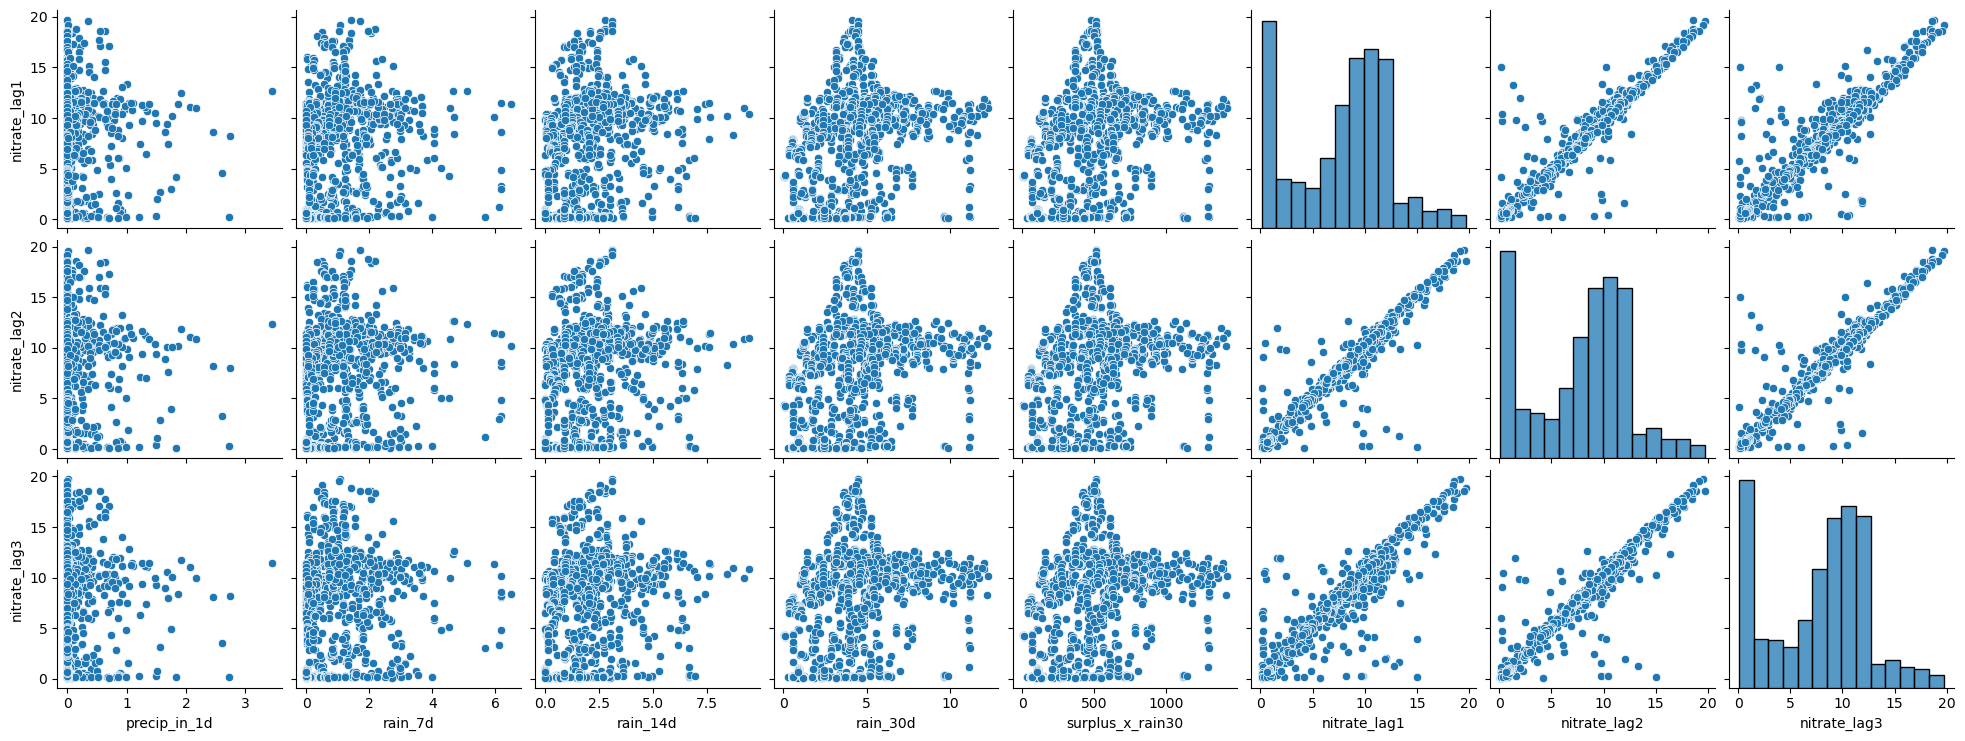

In [152]:
import seaborn as sns

sns.pairplot(train[["precip_in_1d", "rain_7d", "rain_14d", "rain_30d", "surplus_x_rain30", "nitrate_lag1","nitrate_lag2","nitrate_lag3"]], y_vars=["nitrate_lag1","nitrate_lag2","nitrate_lag3"])

The remainder is testing different baseline models on the formatted data.

In [153]:
from scipy.stats import norm
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, mean_absolute_error, mean_squared_error
 

# ------------------------------------------------------------------
# 6. TIME SERIES CROSS-VALIDATION
# TimeSeriesSplit always trains on the past and tests on a later, contiguous
# block -- never shuffles, never tests on data that precedes training data.
# ------------------------------------------------------------------
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=100)
 
results = {k: [] for k in [
    "dummy_most_frequent_AP", "dummy_stratified_AP",
    "gaussian_rw_classifier_AP", "logreg_AP",
    "persistence_regression_MAE", "persistence_regression_RMSE",
    "linreg_MAE", "linreg_RMSE",
]}
 
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    yc_train, yc_test = y_class[train_idx], y_class[test_idx]
    yr_train, yr_test = y_reg[train_idx], y_reg[test_idx]
    today_train, today_test = today_value[train_idx], today_value[test_idx]
 
    print(f"Fold {fold}: train={len(train_idx)}  test={len(test_idx)}  "
          f"test_violations={yc_test.sum()}")
    if yc_test.sum() == 0:
        print("  WARNING: this fold has zero violations -- AP undefined/misleading for it.")
 
    # --- Dummy classifiers (the honest floor) ---
    for strategy, key in [("most_frequent", "dummy_most_frequent_AP"),
                           ("stratified", "dummy_stratified_AP")]:
        dummy = DummyClassifier(strategy=strategy, random_state=0)
        dummy.fit(X_train, yc_train)
        ap = average_precision_score(yc_test, dummy.predict_proba(X_test)[:, 1])
        results[key].append(ap)
 
    # --- Gaussian random walk ---
    # sigma estimated from TRAINING differences only -- no future leakage
    train_diffs = np.diff(today_train)
    sigma = max(np.std(train_diffs), 1e-6) if len(train_diffs) > 1 else 1.0

    # classification view: P(tomorrow > 10 | today) under N(today, sigma^2)
    rw_proba = 1 - norm.cdf((10 - today_test) / sigma)
    results["gaussian_rw_classifier_AP"].append(average_precision_score(yc_test, rw_proba))
 
    # regression view: point forecast = today's value (persistence)
    persistence_pred = today_test
    results["persistence_regression_MAE"].append(mean_absolute_error(yr_test, persistence_pred))
    results["persistence_regression_RMSE"].append(np.sqrt(mean_squared_error(yr_test, persistence_pred)))
 
    # --- Logistic regression (feature-based classification) ---
    logreg = make_pipeline(StandardScaler(),
                            LogisticRegression(class_weight="balanced", max_iter=1000))
    logreg.fit(X_train, yc_train)
    ap_lr = average_precision_score(yc_test, logreg.predict_proba(X_test)[:, 1])
    results["logreg_AP"].append(ap_lr)
 
    # --- Linear regression (feature-based regression) ---
    linreg = make_pipeline(StandardScaler(), LinearRegression())
    linreg.fit(X_train, yr_train)
    lr_pred = linreg.predict(X_test)
    results["linreg_MAE"].append(mean_absolute_error(yr_test, lr_pred))
    results["linreg_RMSE"].append(np.sqrt(mean_squared_error(yr_test, lr_pred)))
 


Fold 0: train=475  test=100  test_violations=38
Fold 1: train=575  test=100  test_violations=13
Fold 2: train=675  test=100  test_violations=6
Fold 3: train=775  test=100  test_violations=25
Fold 4: train=875  test=100  test_violations=19


In [154]:
# ------------------------------------------------------------------
# 7. SUMMARY ACROSS FOLDS
# ------------------------------------------------------------------
print("\n=== Cross-validated results (mean +/- std across folds) ===")
print("\n-- Classification (Average Precision / PR-AUC, higher is better) --")
for key in ["dummy_most_frequent_AP", "dummy_stratified_AP",
            "gaussian_rw_classifier_AP", "logreg_AP"]:
    vals = np.array(results[key])
    print(f"{key:30s}: {vals.mean():.4f} +/- {vals.std():.4f}")
 
print("\n-- Regression (MAE / RMSE in mg/L, lower is better) --")
for key in ["persistence_regression_MAE", "persistence_regression_RMSE",
            "linreg_MAE", "linreg_RMSE"]:
    vals = np.array(results[key])
    print(f"{key:30s}: {vals.mean():.4f} +/- {vals.std():.4f}")
 
# ------------------------------------------------------------------
# HOW TO READ THIS:
# - The Gaussian random walk should beat the dummy classifiers by a wide
#   margin (it has the nontrivial advantage of knowing today's value).
#   If logreg can't beat the random walk, your engineered features (rain,
#   crops, surplus N) aren't adding information beyond "what happened
#   yesterday" -- which is a meaningful, honest finding on its own.
# - Same logic for regression: linreg should beat plain persistence, or
#   your features aren't earning their keep yet.
# ------------------------------------------------------------------
 



=== Cross-validated results (mean +/- std across folds) ===

-- Classification (Average Precision / PR-AUC, higher is better) --
dummy_most_frequent_AP        : 0.2020 +/- 0.1091
dummy_stratified_AP           : 0.1969 +/- 0.0999
gaussian_rw_classifier_AP     : 0.8866 +/- 0.1185
logreg_AP                     : 0.8695 +/- 0.1401

-- Regression (MAE / RMSE in mg/L, lower is better) --
persistence_regression_MAE    : 0.4727 +/- 0.2310
persistence_regression_RMSE   : 1.1036 +/- 0.5702
linreg_MAE                    : 0.5431 +/- 0.2408
linreg_RMSE                   : 1.1342 +/- 0.5928


In [155]:
# Ignore this cell, want to try and model on my own, but obviously haven't gotten very far.

## Import TimeSeriesSplit
from sklearn.model_selection import TimeSeriesSplit

kfold = TimeSeriesSplit(n_splits = 5)

# for train_index, test_index in kfold.split(train):
#     print("TRAIN INDEX SIZE:", train_index)
#     print("TEST INDEX SIZE:", test_index)
#     print()